# Ground Test — AS7341 Multispectral Analysis

## 0 · Imports & paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = Path(r'D:\Masters\Project_leagy_greens\Leafy_Greens_Project\Experiments\ground_test\thesis_data\ground_test')
OUT = Path(r'D:\Masters\Project_leagy_greens\Leafy_Greens_Project\Experiments\plots\ground_test')
OUT.mkdir(parents=True, exist_ok=True)
print('Output folder:', OUT)


Output folder: D:\Masters\Project_leagy_greens\Leafy_Greens_Project\Experiments\plots\ground_test


## 1 · Style

In [2]:
RC  = {1:'#9671bd', 2:'#77b5b6', 3:'#7e7e7e', 4:'#e8a838', 5:'#e05c5c'}
REC = {1:'#6a408d', 2:'#378d94', 3:'#4e4e4e', 4:'#b07010', 5:'#a03030'}
RLS = {1:'-',       2:'--',      3:'-.',       4:':',       5:(0,(3,1,1,1))}
RMK = {1:'o',       2:'s',       3:'^',        4:'D',       5:'v'}
RLB = {1:'Light', 2:'Dark', 3:'Light + Move', 4:'Temp 40 °C', 5:'Humidity 88%'}

CH_COLS = {'f6_590nm':'#e8a838', 'f7_630nm':'#e05c5c',
           'f8_680nm':'#9671bd', 'nir':'#2a9d8f'}
CH_MK   = {'f6_590nm':'o', 'f7_630nm':'s', 'f8_680nm':'^', 'nir':'D'}
CH_LB   = {'f6_590nm':'590 nm', 'f7_630nm':'630 nm',
           'f8_680nm':'680 nm (Deep Red)', 'nir':'855 nm (NIR)'}
CH_LS   = {'f6_590nm':'-', 'f7_630nm':'--', 'f8_680nm':'-.', 'nir':':'}

BAND_C = '#77b5b6'
GREY   = '#8a8a8a'
FS     = 24

plt.rcParams.update({
    'font.family':       'Courier New',
    'font.size':          FS,
    'font.weight':       'bold',
    'axes.titlesize':     FS,
    'axes.titleweight':  'bold',
    'axes.labelsize':     FS,
    'axes.labelweight':  'bold',
    'xtick.labelsize':    FS - 2,
    'ytick.labelsize':    FS - 2,
    'legend.fontsize':    FS - 4,   # slightly smaller so legend fits
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'figure.dpi':         110,
    'savefig.dpi':        200,
    'savefig.bbox':      'tight',
    'pdf.fonttype':        42,
    'svg.fonttype':       'none',
})

def sax(ax):
    ax.grid(True, which='major', linestyle='-', linewidth=0.8,  alpha=0.25)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.15)
    ax.set_axisbelow(True)

def add_legend_above(fig, handles, ncol=3):
    """Place a frameless legend above the axes with enough padding."""
    fig.legend(handles=handles,
               loc='upper center',
               bbox_to_anchor=(0.5, 1.0),   # anchor at top of figure
               ncol=ncol,
               frameon=False,
               columnspacing=1.8,
               handlelength=2.2,
               borderpad=0.4)

def save(fig, name):
    for ext in ['png', 'pdf', 'svg']:
        fig.savefig(OUT / f'{name}.{ext}')
    print(f'  saved  {name}')

cv = lambda v: v.std() / v.mean() * 100 if v.mean() != 0 else float('nan')
dr = lambda v: (v.iloc[-1] - v.iloc[0]) / abs(v.iloc[0]) * 100 if v.iloc[0] != 0 else float('nan')

print('Style ready.')


Style ready.


## 2 · Load data

In [3]:
RUN_DIRS = {
    1: BASE_DIR / 'ground_test_natural_light',
    2: BASE_DIR / 'ground_test_dark',
    3: BASE_DIR / 'ground_test_light_movement',
    4: BASE_DIR / 'ground_test_temp_40degC',
    5: BASE_DIR / 'ground_test_humidity_88%',
}

def load_multi(run):
    df = pd.read_csv(RUN_DIRS[run] / f'ground_multispectral_test{run}.csv',
                     parse_dates=['timestamp'])
    df['t'] = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds() / 60
    return df

m = {r: load_multi(r) for r in [1, 2, 3, 4, 5]}
HIGH_CHANNELS = ['f6_590nm', 'f7_630nm', 'f8_680nm', 'nir']

for r in [1, 2, 3, 4, 5]:
    print(f'Run {r}  {RLB[r]:<18}  rows={len(m[r])}')


Run 1  Light               rows=11
Run 2  Dark                rows=11
Run 3  Light + Move        rows=11
Run 4  Temp 40 °C          rows=11
Run 5  Humidity 88%        rows=11


---
## N1 · NIR (855 nm) — all runs overlaid

  saved  N1_nir_overlay


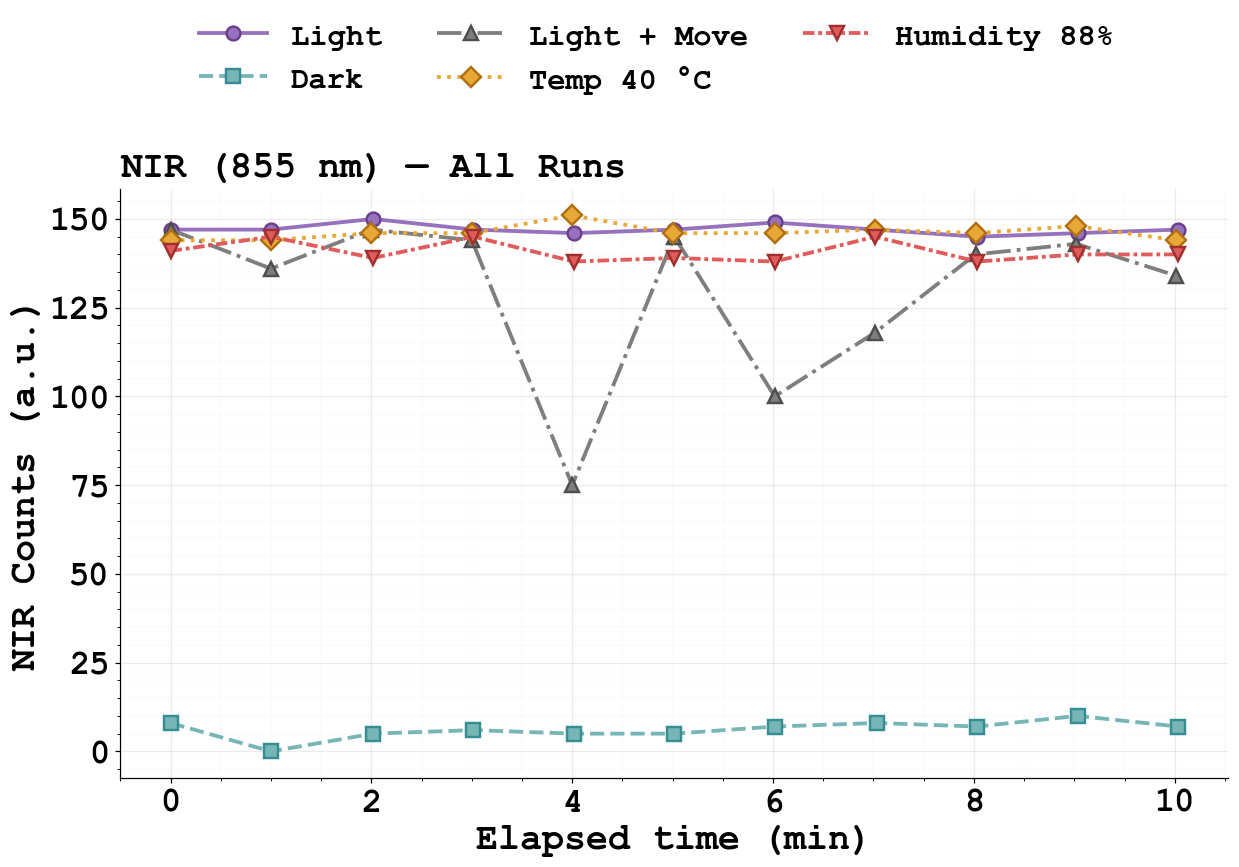

In [4]:
fig, ax = plt.subplots(figsize=(13, 8))
fig.subplots_adjust(top=0.78)   # leave room for legend above
sax(ax)

handles = []
for run in [1, 2, 3, 4, 5]:
    nir = m[run]['nir']
    line, = ax.plot(m[run]['t'], nir,
                    color=RC[run], markerfacecolor=RC[run], markeredgecolor=REC[run],
                    linestyle=RLS[run], linewidth=2.5,
                    marker=RMK[run], markersize=9, markeredgewidth=1.6, zorder=3)
    handles.append(Line2D([0],[0], color=RC[run], linestyle=RLS[run], linewidth=2.5,
                           marker=RMK[run], markersize=9,
                           markerfacecolor=RC[run], markeredgecolor=REC[run],
                           markeredgewidth=1.6, label=RLB[run]))

ax.set_xlabel('Elapsed time (min)')
ax.set_ylabel('NIR Counts (a.u.)')
# Title inside the axes, top-left — no clash with legend
ax.set_title('NIR (855 nm) — All Runs', loc='left', pad=8)

add_legend_above(fig, handles, ncol=3)

save(fig, 'N1_nir_overlay')
plt.show()


---
## N3 · Each channel across all runs

  saved  N3_channel_f6_590nm_all_runs


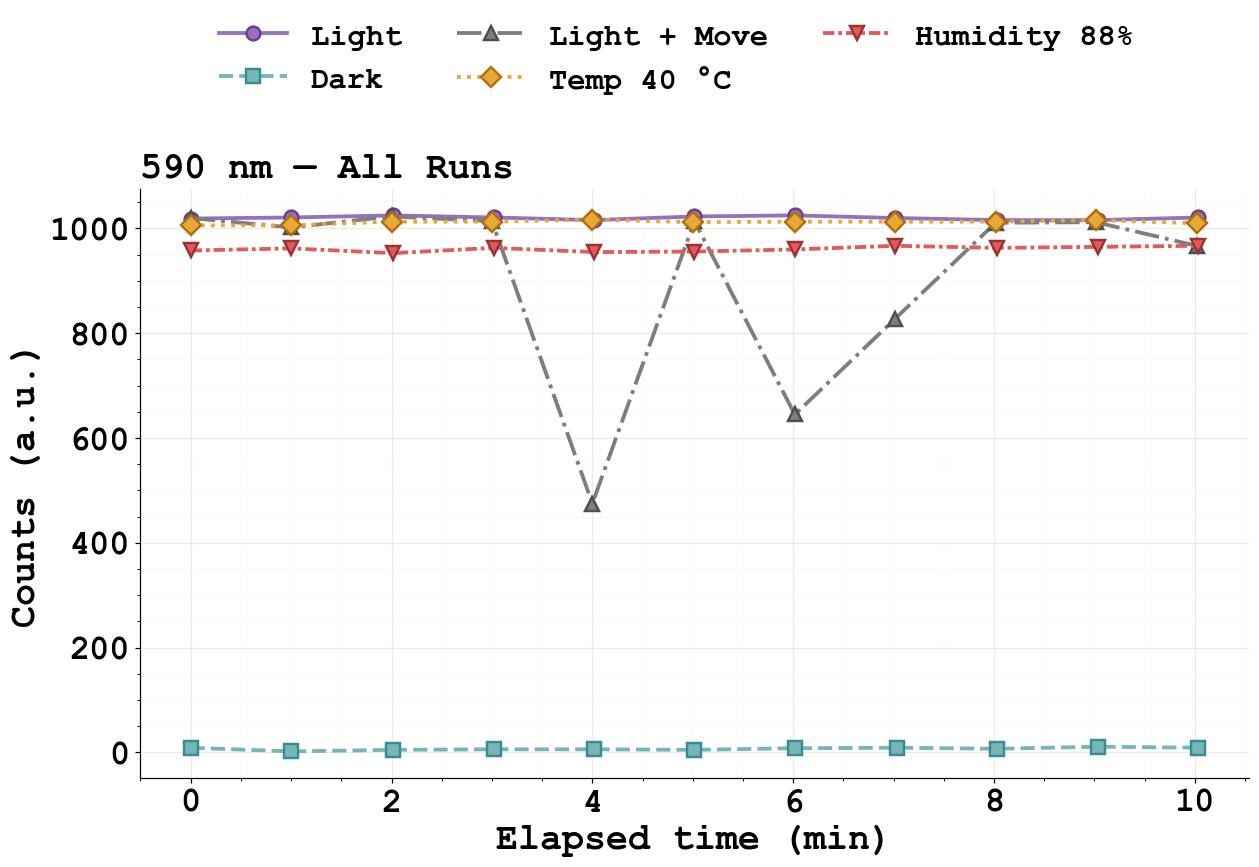

  saved  N3_channel_f7_630nm_all_runs


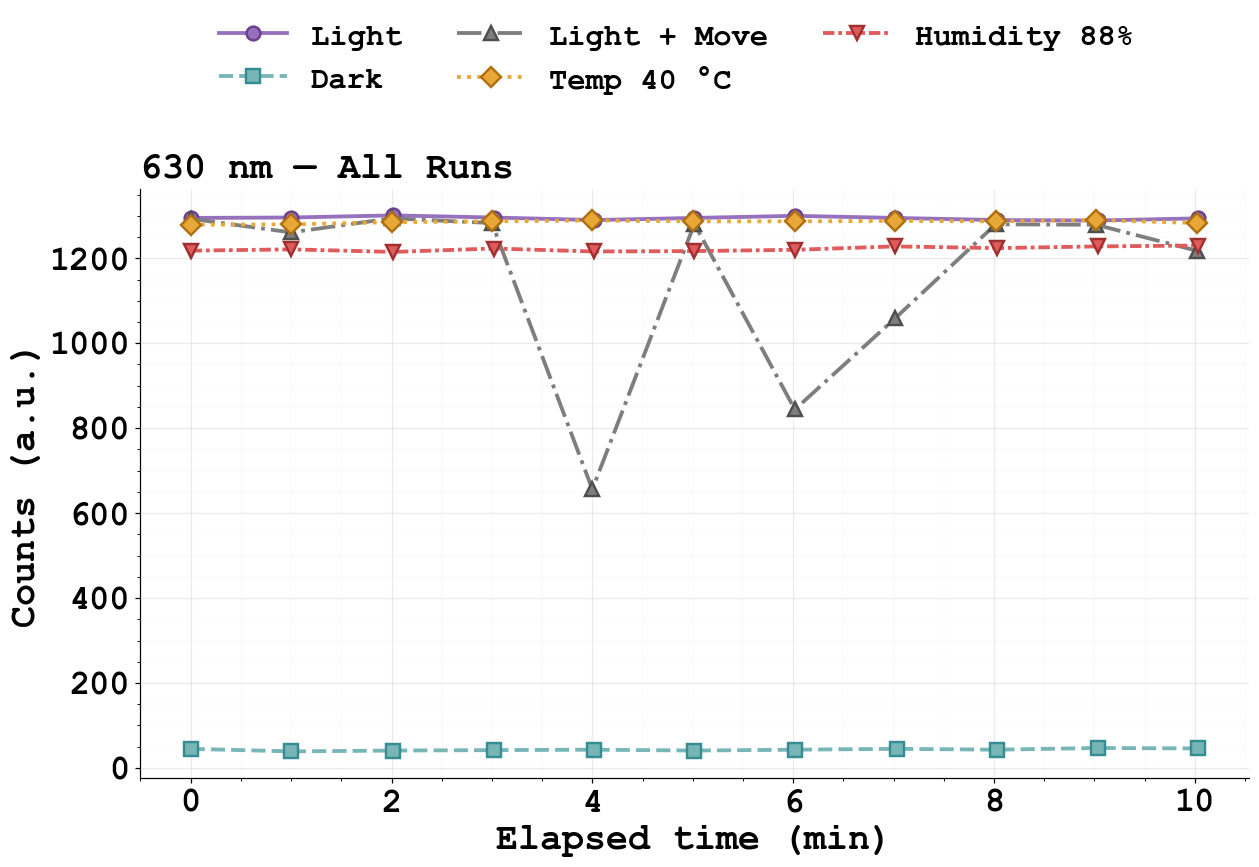

  saved  N3_channel_f8_680nm_all_runs


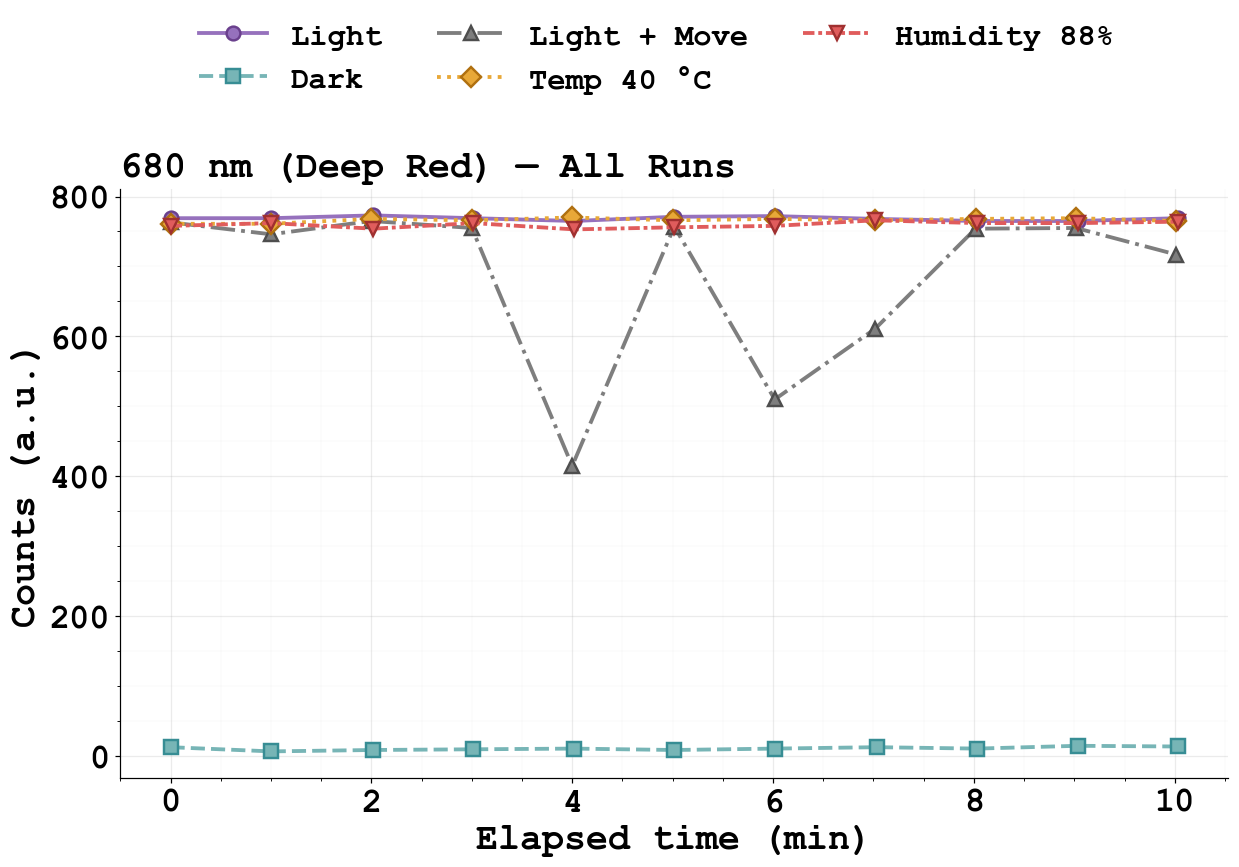

  saved  N3_channel_nir_all_runs


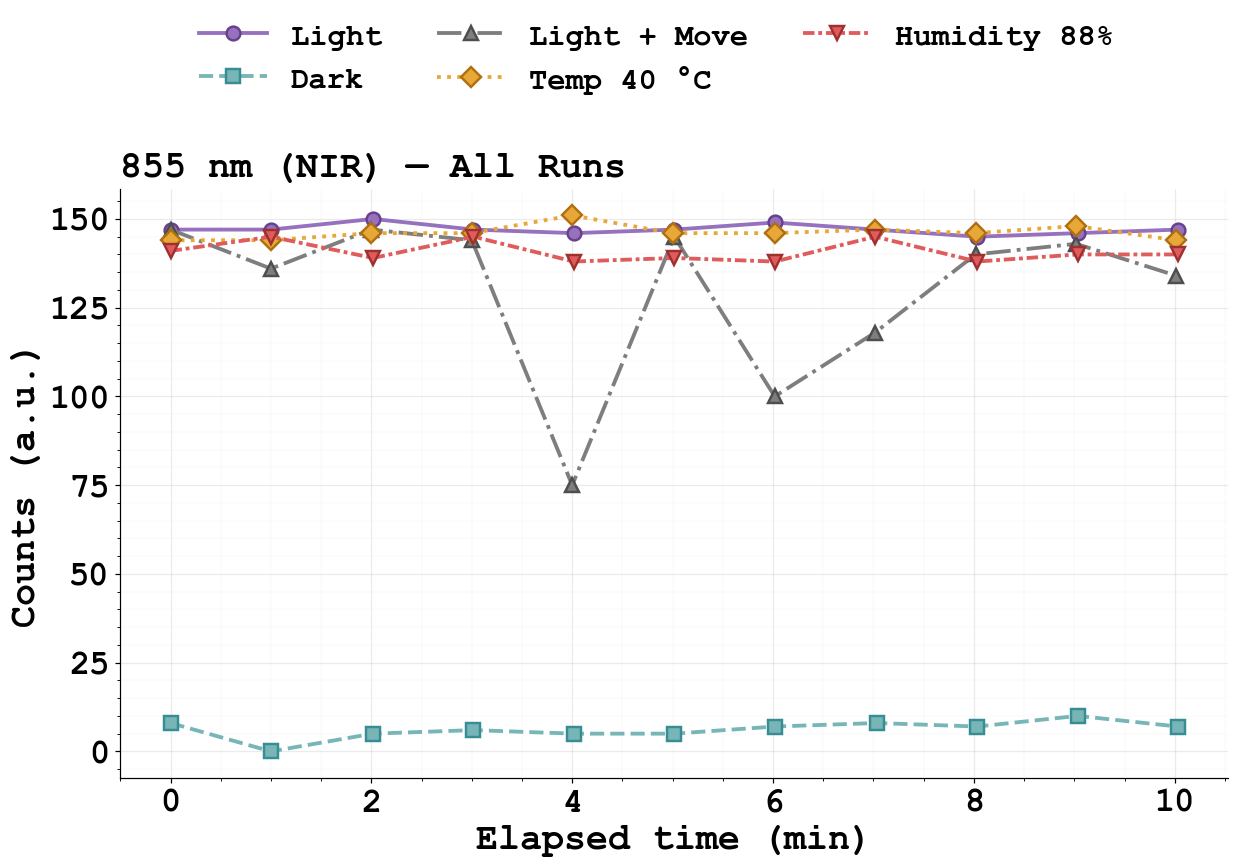

In [6]:
for col in HIGH_CHANNELS:
    fig, ax = plt.subplots(figsize=(13, 8))
    fig.subplots_adjust(top=0.78)
    sax(ax)

    handles = []
    for run in [1, 2, 3, 4, 5]:
        v = m[run][col]
        ax.plot(m[run]['t'], v,
                color=RC[run], linestyle=RLS[run], linewidth=2.5,
                marker=RMK[run], markersize=9, markeredgewidth=1.6,
                markerfacecolor=RC[run], markeredgecolor=REC[run], zorder=3)
        handles.append(Line2D([0],[0], color=RC[run], linestyle=RLS[run],
                               linewidth=2.5, marker=RMK[run], markersize=9,
                               markerfacecolor=RC[run], markeredgecolor=REC[run],
                               markeredgewidth=1.6, label=RLB[run]))

    ax.set_xlabel('Elapsed time (min)')
    ax.set_ylabel('Counts (a.u.)')
    ax.set_title(f'{CH_LB[col]} — All Runs', loc='left', pad=8)

    add_legend_above(fig, handles, ncol=3)

    save(fig, f'N3_channel_{col}_all_runs')
    plt.show()


---
## Summary tables — one per run

In [7]:
CH_LABELS = {'f6_590nm':'590 nm', 'f7_630nm':'630 nm',
             'f8_680nm':'680 nm (Deep Red)', 'nir':'855 nm (NIR)'}

for run in [1, 2, 3, 4, 5]:
    dm   = m[run]
    rows = []
    for col in HIGH_CHANNELS:
        v      = dm[col]
        cv_val = cv(v)
        dr_val = dr(v)
        pass_str = ('— N/A (dark)' if run == 2
                    else ('✓ Pass' if cv_val < 2 else '✗ Fail'))
        rows.append({
            'Channel':  CH_LABELS[col],
            'Mean':     round(v.mean(), 1),
            'SD':       round(v.std(),  2),
            'Min':      round(v.min(),  1),
            'Max':      round(v.max(),  1),
            'CV %':     round(cv_val,   1),
            'Drift %':  round(dr_val,   1),
            'CV < 2%':  pass_str,
        })

    df_run = pd.DataFrame(rows).set_index('Channel')
    display(df_run.style
        .background_gradient(subset=['CV %'],    cmap='RdYlGn_r', vmin=0, vmax=15)
        .background_gradient(subset=['Drift %'], cmap='RdYlGn_r', vmin=-50, vmax=50)
        .format({'Mean':'{:.1f}','SD':'{:.2f}','CV %':'{:.1f}','Drift %':'{:.1f}'})
        .set_caption(f'Run {run} — {RLB[run]}'))
    print()


,Mean,SD,Min,Max,CV %,Drift %,CV < 2%
Channel,,,,,,,
590 nm,1020.3,3.32,1016,1025,0.3,0.2,✓ Pass
630 nm,1294.6,3.85,1289,1301,0.3,-0.1,✓ Pass
680 nm (Deep Red),768.6,2.77,765,773,0.4,0.0,✓ Pass
855 nm (NIR),147.1,1.38,145,150,0.9,0.0,✓ Pass


,Mean,SD,Min,Max,CV %,Drift %,CV < 2%
Channel,,,,,,,
590 nm,7.0,2.53,2,11,36.1,0.0,— N/A (dark)
630 nm,43.2,2.40,39,47,5.6,2.2,— N/A (dark)
680 nm (Deep Red),11.2,2.40,7,15,21.5,7.7,— N/A (dark)
855 nm (NIR),6.2,2.56,0,10,41.4,-12.5,— N/A (dark)


,Mean,SD,Min,Max,CV %,Drift %,CV < 2%
Channel,,,,,,,
590 nm,910.1,185.74,475,1023,20.4,-5.2,✗ Fail
630 nm,1158.9,217.16,656,1294,18.7,-5.8,✗ Fail
680 nm (Deep Red),686.2,120.81,415,765,17.6,-6.0,✗ Fail
855 nm (NIR),129.9,23.21,75,147,17.9,-8.8,✗ Fail


,Mean,SD,Min,Max,CV %,Drift %,CV < 2%
Channel,,,,,,,
590 nm,1012.0,3.49,1006,1017,0.3,0.4,✓ Pass
630 nm,1285.6,3.56,1279,1290,0.3,0.3,✓ Pass
680 nm (Deep Red),766.2,2.96,761,770,0.4,0.5,✓ Pass
855 nm (NIR),146.2,2.04,144,151,1.4,0.0,✓ Pass


,Mean,SD,Min,Max,CV %,Drift %,CV < 2%
Channel,,,,,,,
590 nm,960.8,4.81,953,967,0.5,0.9,✓ Pass
630 nm,1221.8,5.21,1215,1230,0.4,1.0,✓ Pass
680 nm (Deep Red),759.7,4.20,753,766,0.6,0.8,✓ Pass
855 nm (NIR),140.7,2.90,138,145,2.1,-0.7,✗ Fail


---
## T3 · Channel time-series — 2×2 grid per run (publication layout)

Same data as T2 but laid out as a 2×2 grid — one subplot per channel.
This format is cleaner for the report because each channel has its own
y-axis scale, making small variations easier to see.


  saved  T3_grid_run1_Light


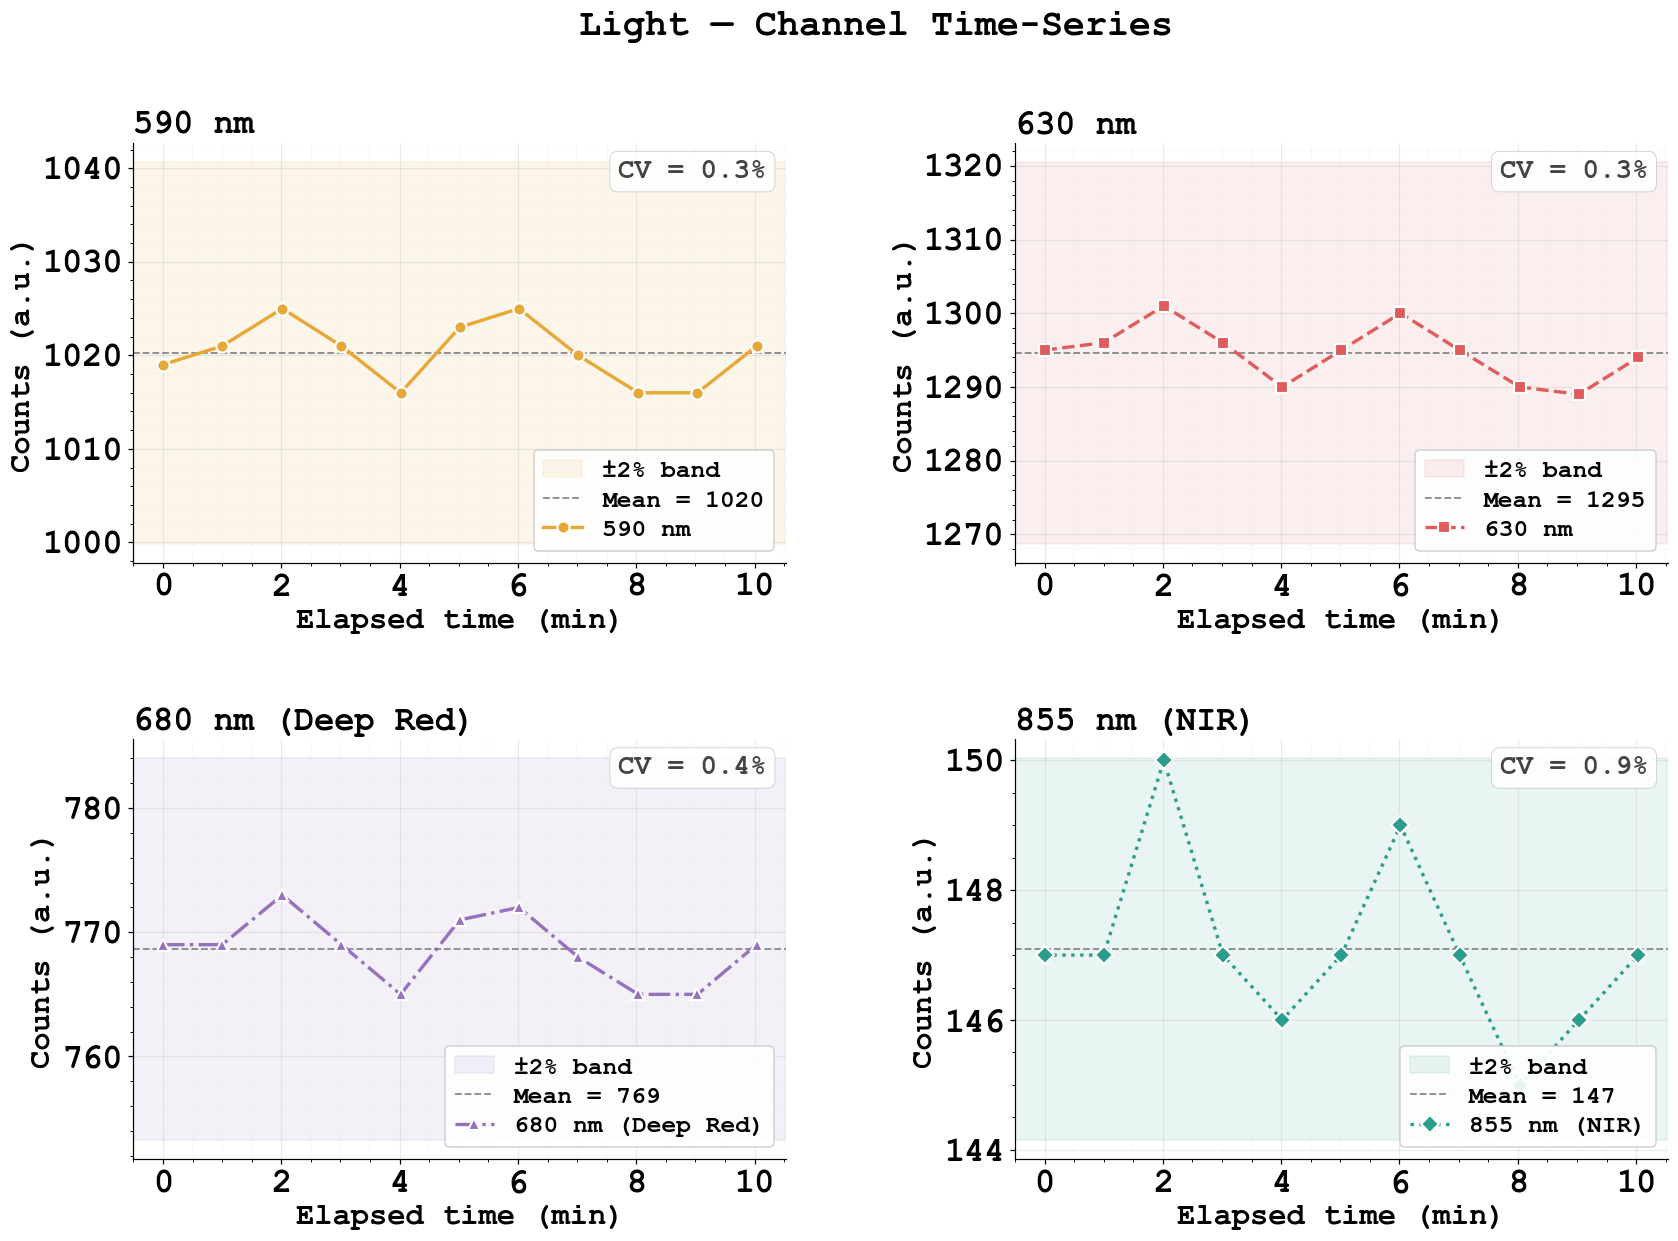

  saved  T3_grid_run2_Dark


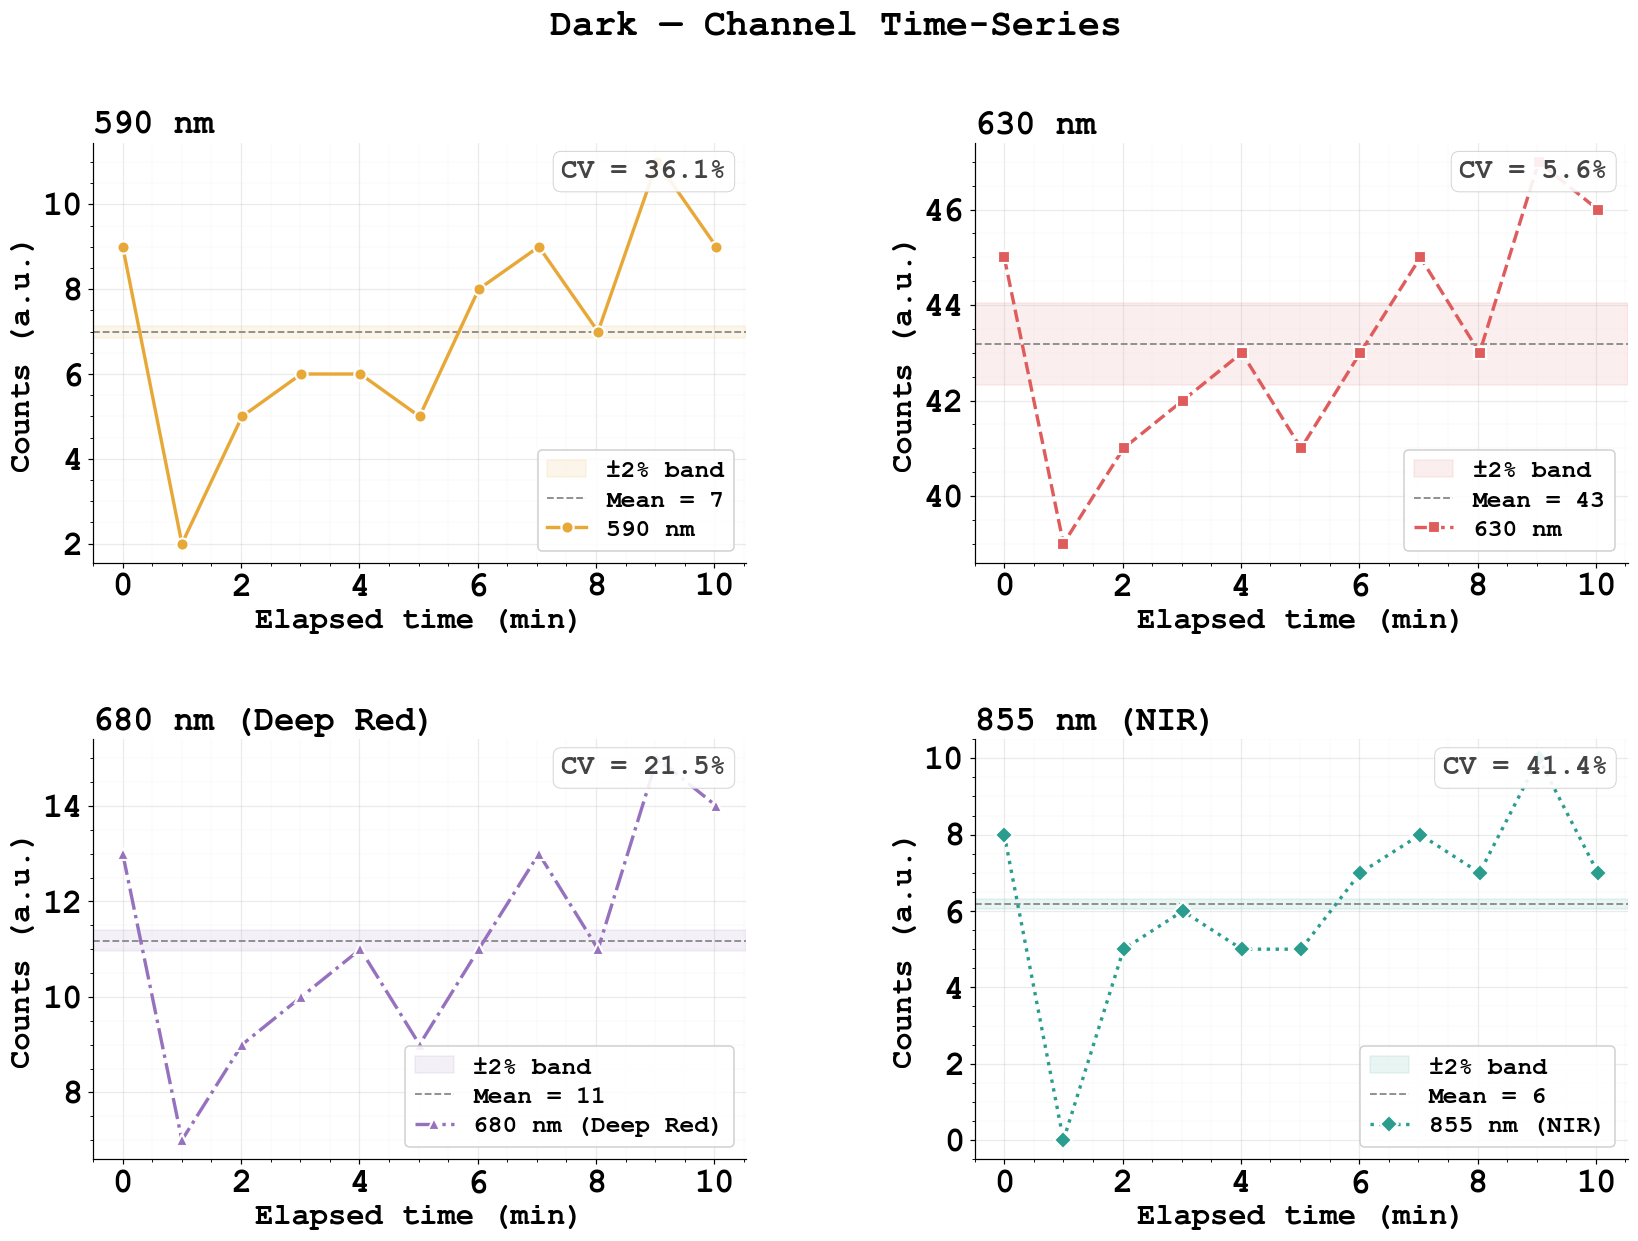

  saved  T3_grid_run3_Light_plus_Move


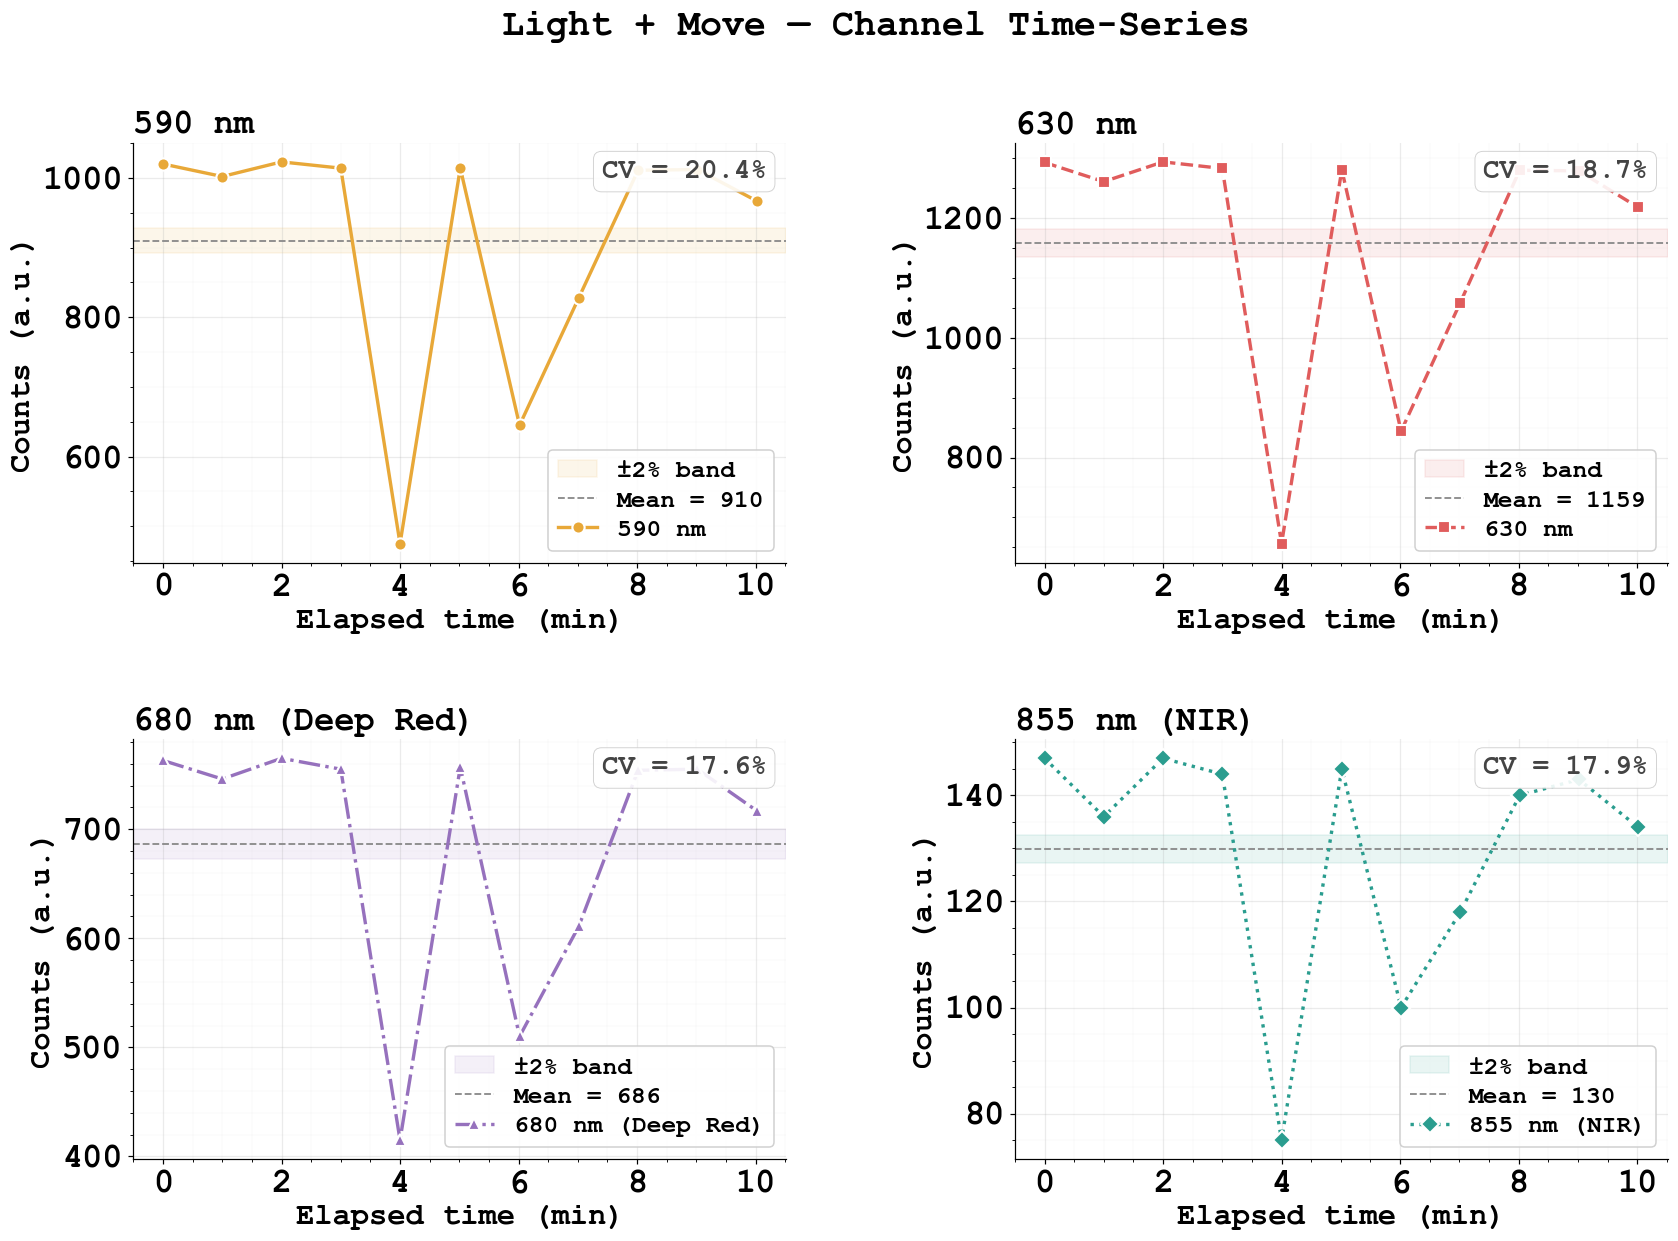

  saved  T3_grid_run4_Temp_40_°C


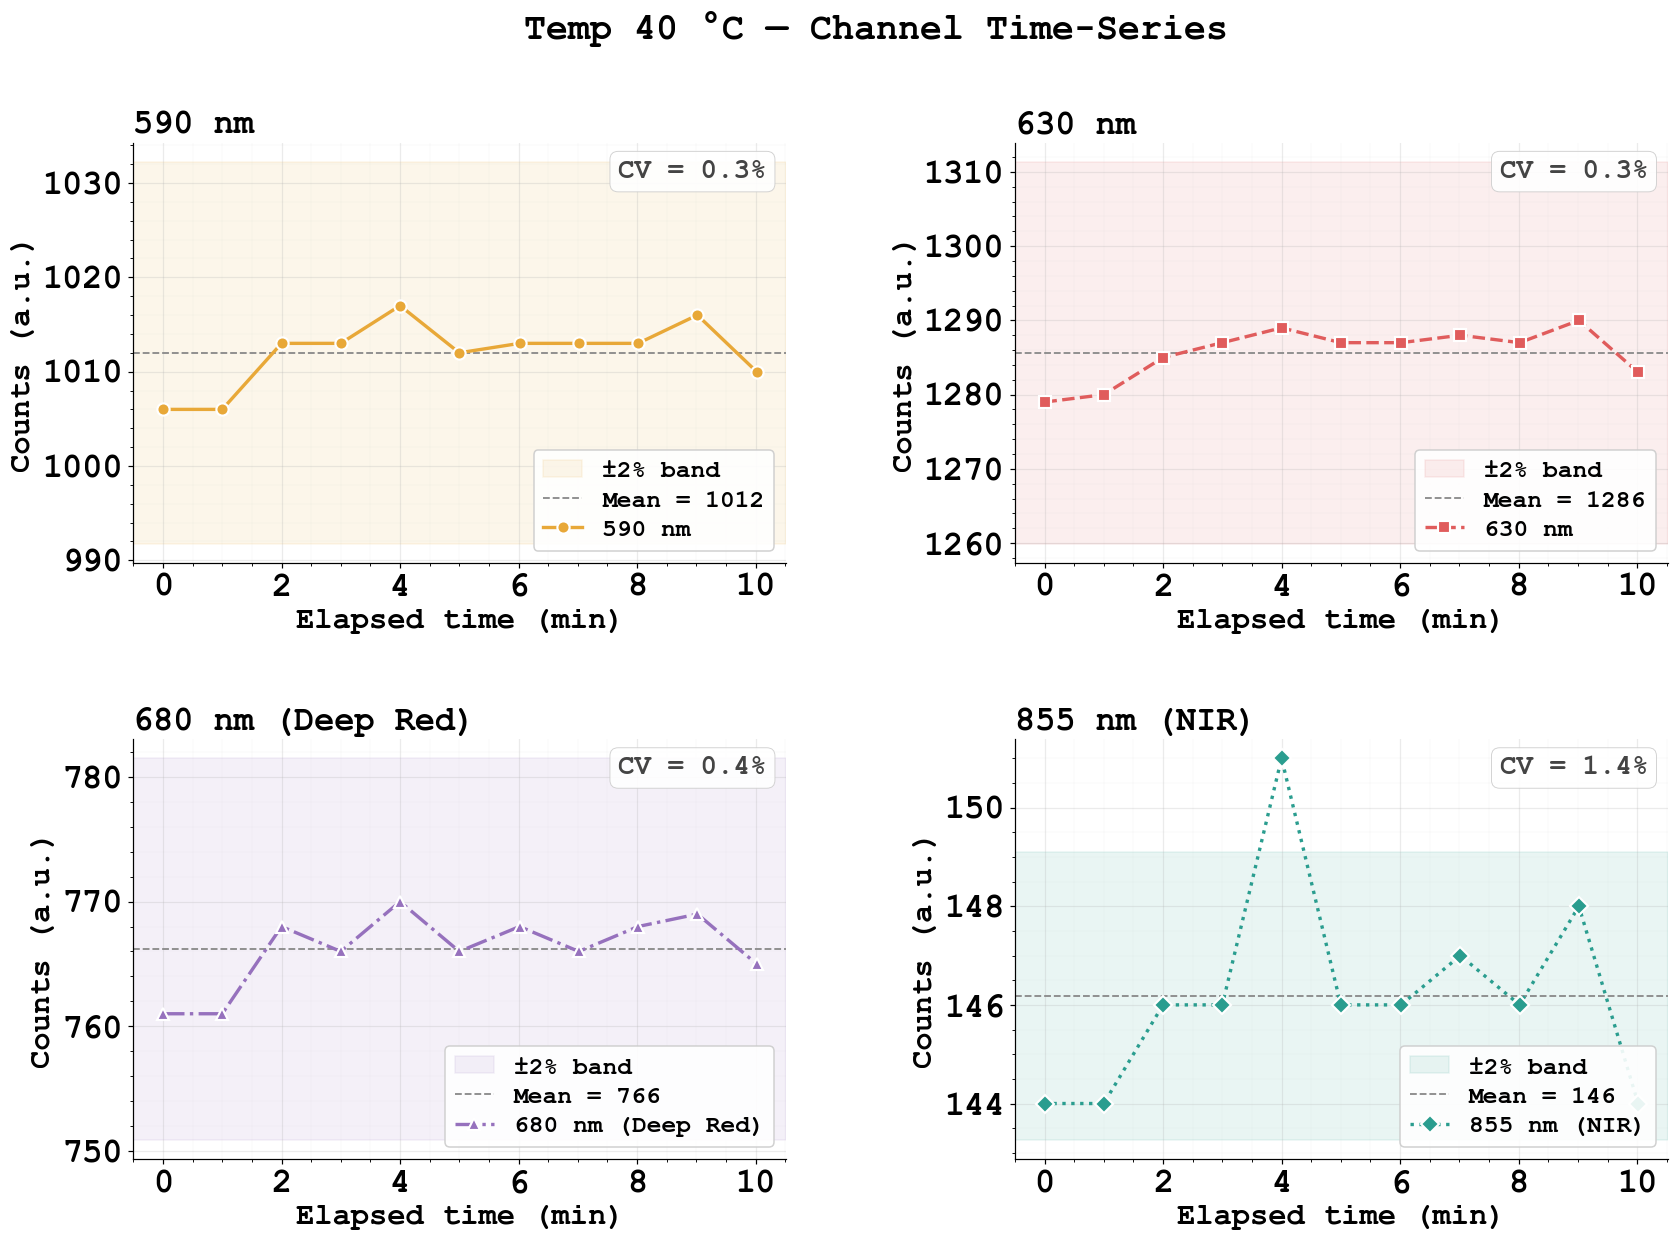

  saved  T3_grid_run5_Humidity_88pct


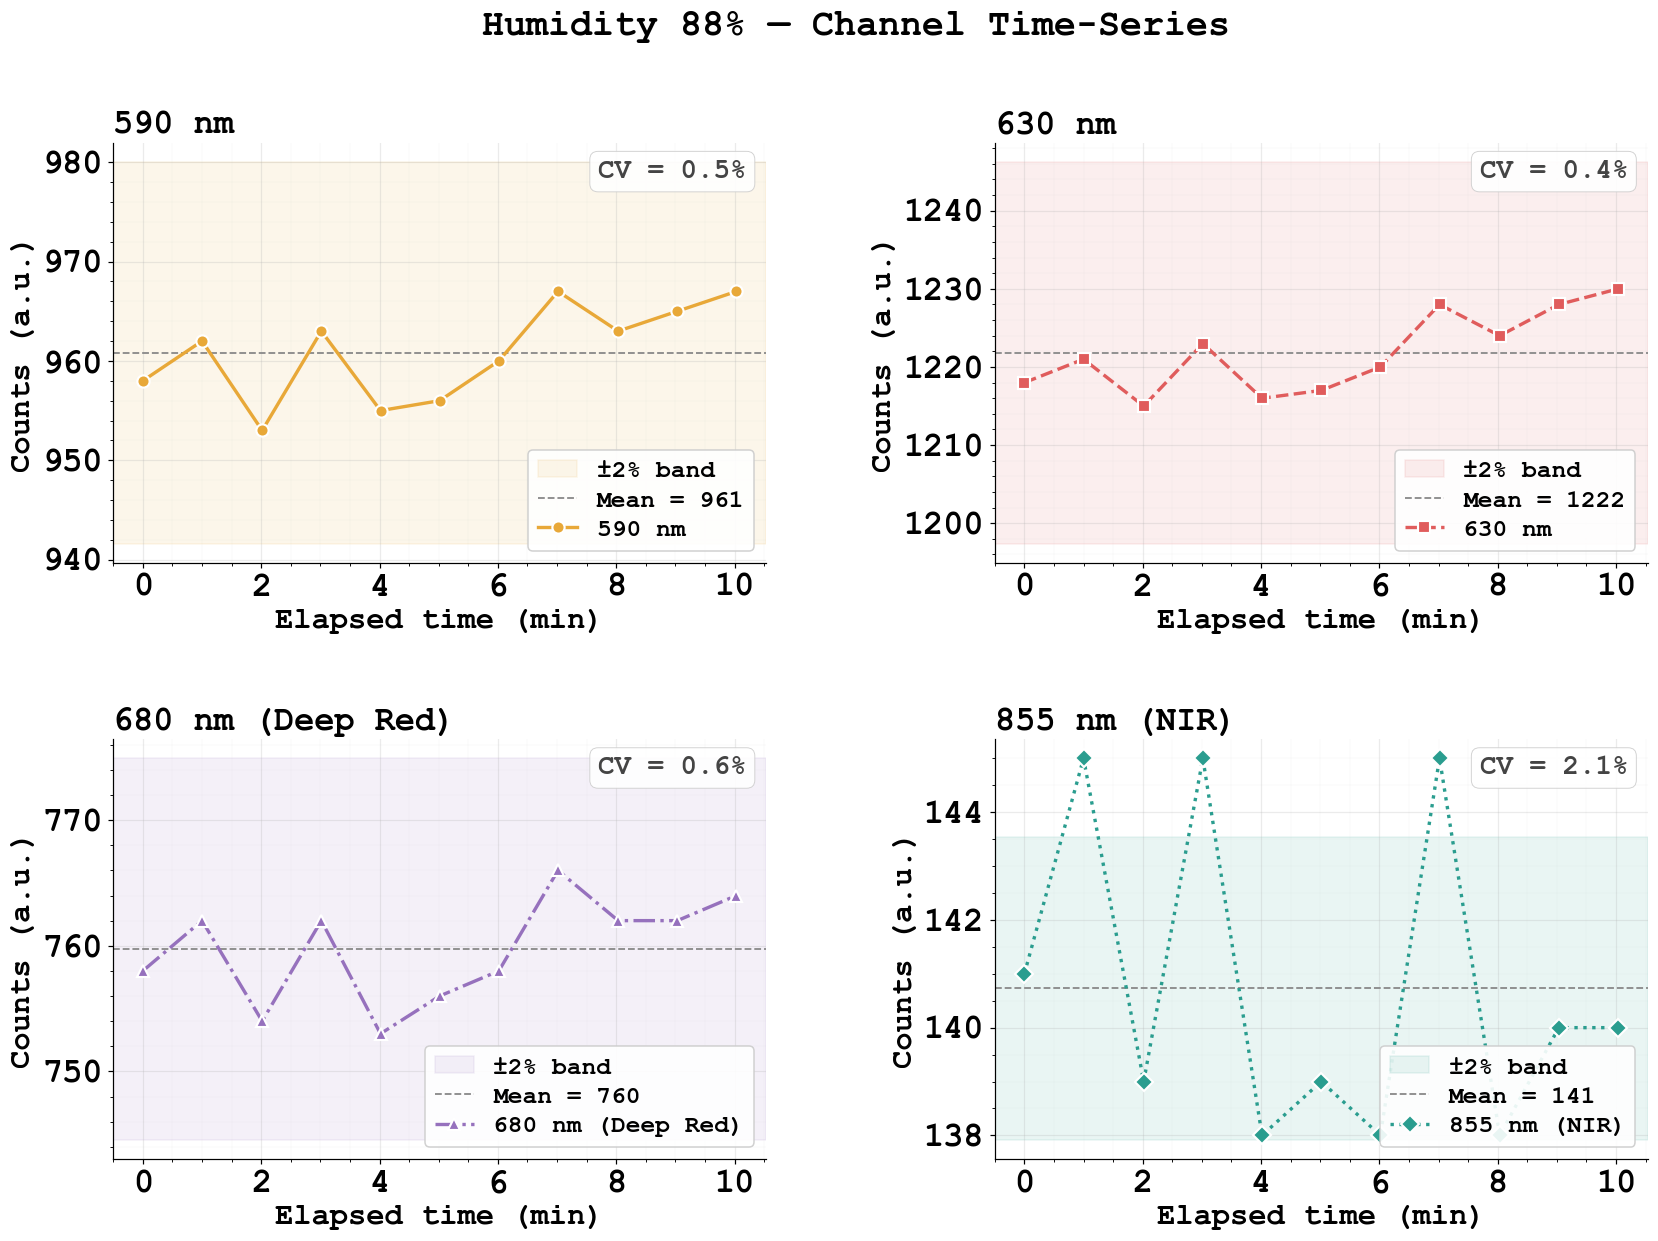

In [10]:
for run in [1, 2, 3, 4, 5]:
    dm = m[run]
    t  = dm['t'].values

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.subplots_adjust(hspace=0.42, wspace=0.35, top=0.88)
    fig.suptitle(f'{RLB[run]} — Channel Time-Series', fontsize=FS, fontweight='bold')

    for ax, col in zip(axes.flat, HIGH_CHANNELS):
        sax(ax)
        v  = dm[col]
        mn = v.mean()

        # ±2% pass band around mean
        ax.axhspan(mn * 0.98, mn * 1.02,
                   color=CH_COLS[col], alpha=0.10, zorder=0, label='±2% band')
        ax.axhline(mn, color=GREY, linewidth=1.2, linestyle='--',
                   zorder=1, label=f'Mean = {mn:.0f}')
        ax.plot(t, v,
                color=CH_COLS[col], linestyle=CH_LS[col], linewidth=2.2,
                marker=CH_MK[col], markersize=8, markeredgewidth=1.4,
                markerfacecolor=CH_COLS[col], markeredgecolor='white', zorder=3,
                label=CH_LB[col])

        # CV annotation inside each panel
        cv_val = cv(v)
        ax.text(0.97, 0.96, f'CV = {cv_val:.1f}%',
                transform=ax.transAxes, fontsize=FS - 6,
                ha='right', va='top', color='#444444',
                bbox=dict(boxstyle='round,pad=0.3', fc='white',
                          ec='#cccccc', lw=0.6, alpha=0.9))

        ax.set_xlabel('Elapsed time (min)', fontsize=FS - 4)
        ax.set_ylabel('Counts (a.u.)',      fontsize=FS - 4)
        ax.set_title(CH_LB[col], loc='left', pad=6, fontsize=FS - 2)
        ax.legend(loc='lower right', frameon=True, framealpha=0.9,
                  edgecolor='#cccccc', fontsize=FS - 8,
                  handlelength=1.6, labelspacing=0.3)

    fname = (f'T3_grid_run{run}_'
             + RLB[run].replace(' ','_').replace('%','pct').replace('+','plus'))
    save(fig, fname)
    plt.show()
